In [2]:
import pandas as pd 

In [14]:
df = pd.read_csv("placement.csv", index_col=0)

In [15]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [17]:
df.shape

(100, 3)

In [19]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


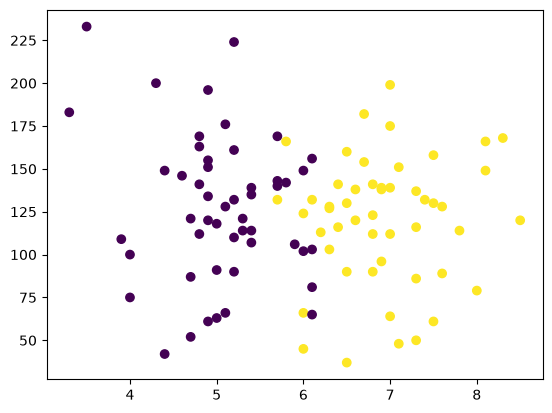

In [21]:
plt.scatter(df["cgpa"], df["iq"], c=df["placement"])

In [22]:
X = df.iloc[:, 0: 2]

In [23]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [27]:
y = df.iloc[:, -1]

In [28]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [29]:
y.shape

(100,)

In [31]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1) # 10% data will be split to test dataset.

In [34]:
X_train

,cgpa,iq
75,4.8,169.0
1,5.9,106.0
18,4.0,100.0
17,3.3,183.0
35,6.8,90.0
...,...,...
78,6.1,81.0
12,5.4,139.0
30,7.6,128.0
19,5.2,132.0


In [35]:
y_train

75    0
1     0
18    0
17    0
35    1
     ..
78    0
12    0
30    1
19    0
50    0
Name: placement, Length: 90, dtype: int64

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scalar = StandardScaler()

In [40]:
X_train = scalar.fit_transform(X_train)

In [41]:
X_train

array([[-1.01829613,  1.18117013],
       [-0.04988771, -0.44279559],
       [-1.72259316, -0.597459  ],
       [-2.33885306,  1.54205141],
       [ 0.74244645, -0.85523133],
       [-0.930259  ,  0.27896695],
       [-0.22596196,  0.43363035],
       [-0.930259  ,  0.82028886],
       [ 0.39029794, -0.18502326],
       [-0.75418474,  0.12430355],
       [-1.81063029, -0.36546389],
       [-0.22596196,  0.22741248],
       [ 0.21422368, -0.26235496],
       [-0.84222187, -0.8294541 ],
       [ 0.83048358, -0.70056793],
       [-1.37044464, -2.09253855],
       [-0.66614761, -0.85523133],
       [-0.930259  ,  1.87715545],
       [-0.84222187, -1.55121665],
       [ 0.47833507,  0.94917503],
       [ 0.03814942, -2.01520685],
       [-0.49007335, -0.41701836],
       [ 0.12618655, -1.49966218],
       [ 0.74244645,  0.45940759],
       [ 0.47833507,  0.17585802],
       [ 0.91852071,  0.40785312],
       [-0.22596196,  1.18117013],
       [-1.10633325, -0.05613709],
       [-0.49007335,

In [43]:
X_test = scalar.transform(X_test)

In [44]:
X_test

array([[-0.75418474, -1.47388494],
       [ 0.47833507, -2.22142472],
       [ 1.62281774, -0.23657772],
       [ 1.88692913,  0.66562546],
       [ 1.00655784,  0.71717993],
       [ 0.47833507, -0.85523133],
       [-0.13792484,  1.10383843],
       [-0.22596196,  0.51096206],
       [ 0.12618655,  0.8460661 ],
       [-1.45848177,  1.98026438]])

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
clf = LogisticRegression()

In [47]:
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [49]:
y_pred = clf.predict(X_test)

In [50]:
y_pred

array([0, 1, 1, 1, 1, 1, 0, 0, 1, 0])

In [51]:
from sklearn.metrics import classification_report

In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.83      0.83      0.83         6

    accuracy                           0.80        10
   macro avg       0.79      0.79      0.79        10
weighted avg       0.80      0.80      0.80        10



In [57]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

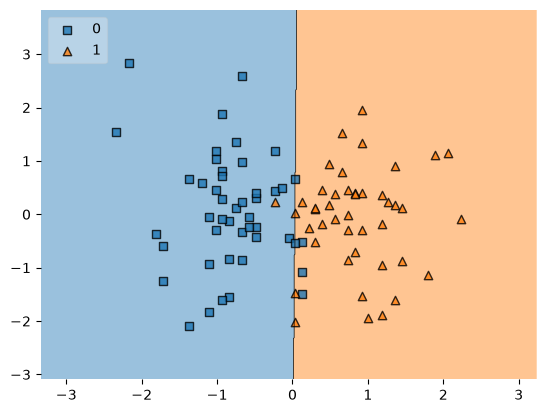

In [58]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)